In [21]:
import re
from pathlib import Path
import numpy as np
from PIL import Image

# ==========================================
# НАСТРОЙКИ ПУТЕЙ
# ==========================================
# Корневая папка лабораторной работы
BASE_DIR = Path(r"C:\Users\RedBrean\Documents\MIPT\term2\MQO\experiment_theory")
INPUT_DIR = Path(r"C:\Users\RedBrean\Pictures\RQC\2026-07-17")
# INPUT_DIR = BASE_DIR / "raw_data"
OUTPUT_DIR = BASE_DIR / "processed"

# Создаем выходную директорию, если её нет
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# ФУНКЦИИ ОБРАБОТКИ ИЗОБРАЖЕНИЙ
# ==========================================

def load_image(filepath: Path) -> np.ndarray:
    """Загружает PNG изображение как float64 массив."""
    with Image.open(filepath) as img:
        return np.array(img, dtype=np.float64)


def combine_images(filepaths: list[Path], method: str = "median") -> np.ndarray:
    """
    Аккуратно объединяет стек изображений.
    'median' — убирает случайные шумы и горячие пиксели (рекомендуется).
    'mean'   — классическое усреднение.
    """
    if not filepaths:
        raise ValueError("Список файлов для объединения пуст.")
    
    stack = np.stack([load_image(f) for f in filepaths])
    
    if method == "median":
        return np.median(stack, axis=0)
    return np.mean(stack, axis=0)


def save_image(arr: np.ndarray, filepath: Path) -> None:
    """Сохраняет массив как PNG, автоматически определяя разрядность (8/16 бит)."""
    # Обрезаем значения, чтобы не вылететь за границы диапазона
    arr_clipped = np.clip(arr, 0, 65535)

    # Если исходный макс был небольшой, сохраняем в 8 бит, иначе в 16 бит
    if arr_clipped.max() <= 255:
        arr_rescaled = arr_clipped.astype(np.uint8)
    else:
        arr_rescaled = arr_clipped.astype(np.uint16)

    Image.fromarray(arr_rescaled).save(filepath)


# ==========================================
# ГРУППИРОВКА ФАЙЛОВ
# ==========================================

groups = {}

for file in INPUT_DIR.glob("*.png"):
    name = file.stem

    # 1. Отбрасываем дату/время (все, что с _YYYY-MM-DD...)
    prefix = re.sub(r'_\d{4}-\d{2}-\d{2}T.*$', '', name)

    # 2. Разбираем типы кадров и оставляем суффикс _F у групп с фильтром
    if prefix.endswith('_FN'):
        kind = "noise"
        key = prefix[:-1]  # превращаем '2_0_FN' -> '2_0_F' (группа с фильтром)
    elif prefix.endswith('_N'):
        kind = "noise"
        key = prefix[:-2]  # превращаем '2_0_N'  -> '2_0' (обычная группа)
    elif prefix.endswith('_F'):
        kind = "signal"
        key = prefix       # остается '2_0_F'
    else:
        kind = "signal"
        key = prefix       # остается '2_0'

    groups.setdefault(key, {"signal": [], "noise": []})
    groups[key][kind].append(file)

# ==========================================
# ОСНОВНОЙ ЦИКЛ ОБРАБОТКИ
# ==========================================

print(f"Старт обработки файлов из: {INPUT_DIR}\n" + "-"*50)

for key, data in sorted(groups.items()):
    signal_files = data["signal"]
    noise_files = data["noise"]

    if not signal_files:
        print(f"Предупреждение: Для группы '{key}' нет файлов сигнала. Пропускаем.")
        continue

    print(f"Обработка группы: {key}")
    print(f"  └─ Сигнальных кадров: {len(signal_files)}")
    print(f"  └─ Шумовых кадров (dark frames): {len(noise_files)}")

    # Усредняем медианой для защиты от выбросов
    signal_avg = combine_images(signal_files, method="mean")

    if noise_files:
        noise_avg = combine_images(noise_files, method="mean")
        # Вычитание темнового кадра (шума)
        result = signal_avg - noise_avg
    else:
        result = signal_avg

    # Убираем отрицательные пиксели, которые могли возникнуть при вычитании шума
    result = np.maximum(result, 0)

    # Сохраняем результат
    output_path = OUTPUT_DIR / f"{key}.png"
    save_image(result, output_path)

print("-"*50)
print("Готово! Чистые данные лежат здесь:")
print(OUTPUT_DIR)

Старт обработки файлов из: C:\Users\RedBrean\Pictures\RQC\2026-07-17
--------------------------------------------------
Обработка группы: 2_0
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_0_F
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_12
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_12_F
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_15
  └─ Сигнальных кадров: 12
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_15_F
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_18
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_18_F
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_21
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark frames): 10
Обработка группы: 2_21_F
  └─ Сигнальных кадров: 10
  └─ Шумовых кадров (dark fram

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns  # Удобно для красивых графиков с группировкой
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from sklearn.metrics import r2_score


class CrystalExperiment:
    """
    Класс отдельного эксперимента.
    Хранит метаданные в виде произвольного словаря, осуществляет калибровку
    и анализ интерференционной картины. Все результаты сохраняются в поля класса.
    """
    C_LIGHT = 299_792_458

    def __init__(self, filter_filename, nofilter_filename, metadata=None, config=None):
        self.filter_filename = filter_filename
        self.nofilter_filename = nofilter_filename
        
        # Хранилище для любых параметров эксперимента (дистанция, щель, ток и т.д.)
        self.metadata = metadata if metadata is not None else {}
        
        if config is None:
            config = {
            "left": 230, "right": 400,
            "top": 140, "bottom": 350,
            "target_wavelength": 808.0,
            "stripe_width": 3,
            "savgol_window": 21,       
            "savgol_poly": 7,          
            "peak_prominence": 0.05,   
            "valley_prominence": 0.05, 
            "peak_distance": 6,        
            "peak_height_min": 0.12,  
            "input_dir": "processed",
            "output_dir": "analysis_output"
            }
        self.config = config

        self.filter_dir = os.path.join(config["output_dir"], "filter_fits")
        self.nofilter_dir = os.path.join(config["output_dir"], "nofilter_spectra")

        # --- ПОЛЯ КЛАССА ДЛЯ ХРАНЕНИЯ РЕЗУЛЬТАТОВ ---
        # Результаты калибровки (Fit)
        self.alpha = None
        self.beta = None
        self.shift = None
        self.scale = None
        self.r2 = None
        
        # Массивы данных
        self.img_nf = None
        self.crop_nf = None
        self.spectrum_nf = None
        self.slice_808 = None
        self.smoothed_slice = None
        
        # Экстремумы и координаты
        self.pixel808 = None
        self.peaks_idx = []
        self.valleys_idx = []
        self.paired_extrema = []  
        self.local_visibilities = []

        # Ключевые физические метрики
        self.visibility = 0.0
        self.intensity_max_slice = 0.0  
        self.intensity_808_exact = 0.0
        self.intensity_808_avg = 0.0
        self.intensity_total = 0.0
        
        self.log_line = ""

    @staticmethod
    def _gaussian(w, w0, sig):
        return np.exp(-0.5 * ((w - w0) / sig) ** 2)

    @staticmethod
    def _convert_w_to_l(func, w_range, *params):
        """
        Преобразует спектральную плотность I(w) в I(lambda) с учетом Якобиана:
        I(lambda) = I(w) * |dw/dlambda| ~ I(w) * w^2
        """
        y_w = func(w_range, *params)
        # Якобиан перехода dw/dlambda proportional to w^2
        y_l = y_w * (w_range ** 2)
        
        max_val = np.max(y_l)
        if max_val > 0:
            y_l /= max_val
        return y_l

    @staticmethod
    def _gfit(pix, alpha, beta, shift, scale):
        wavelength = shift + scale * pix
        c_factor = 2 * np.pi * CrystalExperiment.C_LIGHT * 1e-3  # мкм * рад / с или нм эквивалент
        
        # Предотвращаем деление на ноль, если алгоритм оптимизации предложит wavelength <= 0
        wavelength = np.maximum(wavelength, 1e-5)
        ang_freq = c_factor / wavelength
        
        l0 = 810.0
        l_fwhm = 10.0
        w0 = c_factor / l0
        w_fwhm = c_factor * l_fwhm / (l0**2 - (l_fwhm / 2)**2)
        sig_w = w_fwhm / (2 * np.sqrt(2 * np.log(2)))
        
        y_l = CrystalExperiment._convert_w_to_l(CrystalExperiment._gaussian, ang_freq, w0, sig_w)
        return beta + alpha * y_l
    def _load_image(self, filename):
        """
        Загружает изображение с дискретизацией в float32 и безопасным закрытием файла.
        Путь к папке берется из config['input_dir'] (по умолчанию 'processed').
        """
        input_dir = self.config.get("input_dir", "processed")
        filepath = os.path.join(input_dir, filename)
        
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Файл изображения не найден: {filepath}")
            
        with Image.open(filepath) as img_raw:
            img = np.array(img_raw.convert("L"), dtype=np.float32)
            
        max_val = np.max(img)
        if max_val > 0:
            img /= max_val
        return img

    def _get_crop(self, img):
        return img[self.config["top"]:self.config["bottom"], self.config["left"]:self.config["right"]]

    def _get_meta_string(self):
        """Красивая строка со всеми параметрами для графиков и логов"""
        if not self.metadata:
            return "No Meta"
        return ", ".join([f"{k}: {v}" for k, v in self.metadata.items()])

    def run_calibration(self):
        """
        Проводит калибровку спектрометра по фильтру.
        Начальные приближения (p0) и границы (bounds) авто-рассчитываются 
        на основе параметров кропа и геометрии кадра.
        """
        img = self._load_image(self.filter_filename)
        crop = self._get_crop(img)
        
        left = self.config["left"]
        right = self.config["right"]
        target_wl = self.config.get("target_wavelength", 808.0)
        
        x_pix = np.arange(left, right)
        
        # Интегрируем по вертикали для получения спектрального профиля
        y_exp = np.trapezoid(crop, axis=0)
        max_y = np.max(y_exp)
        if max_y > 0:
            y_exp /= max_y

        # --- ДИНАМИЧЕСКИЙ РАСЧЕТ НАЧАЛЬНЫХ ПАРАМЕТРОВ (p0) ---
        crop_center_pix = (left + right) / 2.0
        
        # 1. Начальный масштаб (нм/пиксель)
        init_scale = self.config.get("initial_scale", 0.2)
        
        # 2. Начальный сдвиг: подбираем так, чтобы target_wavelength попадал примерно в центр кропа
        init_shift = target_wl - (crop_center_pix * init_scale)
        
        # 3. Фон (beta): медиана минимальных значений на краях спектра
        edge_len = max(1, len(y_exp) // 10)
        init_beta = float(np.median(np.concatenate([y_exp[:edge_len], y_exp[-edge_len:]])))
        
        # 4. Амплитуда пика (alpha)
        init_alpha = max(0.1, float(np.max(y_exp) - init_beta))

        p0 = [init_alpha, init_beta, init_shift, init_scale]

        # --- ДИНАМИЧЕСКИЕ ГРАНИЦЫ (BOUNDS) ---
        # Не позволяем shift уходить слишком далеко за пределы разумной окрестности кропа
        min_shift = target_wl - (right * 2.0)
        max_shift = target_wl - (left * 0.05)
        
        bounds = (
            [0.0, 0.0, min_shift, 0.01],         # Нижние границы [alpha, beta, shift, scale]
            [np.inf, 1.0, max_shift, 2.0]        # Верхние границы
        )

        try:
            popt, _ = curve_fit(
                self._gfit, 
                x_pix, 
                y_exp, 
                p0=p0, 
                bounds=bounds,
                maxfev=10000
            )
            y_fit = self._gfit(x_pix, *popt)
            
            self.alpha = float(popt[0])
            self.beta = float(popt[1])
            self.shift = float(popt[2])
            self.scale = float(popt[3])
            self.r2 = float(r2_score(y_exp, y_fit))

        except (RuntimeError, ValueError) as e:
            print(f"[Warning] Калибровка для {self.filter_filename} не сошлась: {e}")
            # Фоллбэк на автоматически рассчитанные p0
            self.alpha, self.beta, self.shift, self.scale = p0
            y_fit = self._gfit(x_pix, *p0)
            self.r2 = 0.0

        # Сохраняем временно для построения индивидуального графика калибровки
        self._tmp_calib = {
            "image": img, 
            "crop": crop, 
            "x_pix": x_pix, 
            "y_exp": y_exp, 
            "y_fit": y_fit
        }

    def process_nofilter_data(self):
        if self.shift is None or self.scale is None:
            raise ValueError("Калибровка не проведена или завершилась с ошибкой!")

        self.img_nf = self._load_image(self.nofilter_filename)
        self.crop_nf = self._get_crop(self.img_nf)
        self.spectrum_nf = np.trapezoid(self.crop_nf, axis=0)

        self.pixel808 = (self.config["target_wavelength"] - self.shift) / self.scale
        pixel_local = int(round(self.pixel808)) - self.config["left"]

        # 1. Метрики интенсивности из горизонтального спектра
        if 0 <= pixel_local < len(self.spectrum_nf):
            self.intensity_808_exact = self.spectrum_nf[pixel_local]
        else:
            self.intensity_808_exact = 0.0

        radius = 2
        w_start = max(0, pixel_local - radius)
        w_end = min(len(self.spectrum_nf), pixel_local + radius + 1)
        self.intensity_808_avg = np.mean(self.spectrum_nf[w_start:w_end]) if w_start < w_end else 0.0

        self.intensity_total = np.trapezoid(self.spectrum_nf)

        # 2. Вертикальный срез интерференции (анализ по оси Y)
        half_width = self.config["stripe_width"] // 2
        start_x = max(0, pixel_local - half_width)
        stop_x = min(self.crop_nf.shape[1], pixel_local + half_width + 1)
        self.slice_808 = np.mean(self.crop_nf[:, start_x:stop_x], axis=1)

        w_len = self.config["savgol_window"]
        p_order = self.config["savgol_poly"]
        if w_len >= len(self.slice_808):
            w_len = len(self.slice_808) if len(self.slice_808) % 2 != 0 else len(self.slice_808) - 1
        self.smoothed_slice = savgol_filter(self.slice_808, window_length=w_len, polyorder=p_order)

        self.intensity_max_slice = np.max(self.smoothed_slice)

        # 3. Поиск экстремумов интерференции
        peaks, _ = find_peaks(
            self.smoothed_slice, 
            prominence=self.config["peak_prominence"], 
            distance=self.config["peak_distance"],
            height=self.config["peak_height_min"]
        )
        self.peaks_idx = peaks

        valleys = []
        if len(peaks) >= 2:
            p_left = peaks[0]
            p_right = peaks[-1]
            valley_zone = -self.smoothed_slice[p_left:p_right]
            valleys_local, _ = find_peaks(
                valley_zone, 
                prominence=self.config["valley_prominence"], 
                distance=self.config["peak_distance"]
            )
            valleys = valleys_local + p_left
        self.valleys_idx = valleys

        extrema_list = []
        for p in peaks: extrema_list.append((p, 'max', self.smoothed_slice[p]))
        for v in valleys: extrema_list.append((v, 'min', self.smoothed_slice[v]))
        extrema_list.sort(key=lambda x: x[0])

        self.local_visibilities = []
        self.paired_extrema = []
        for i in range(len(extrema_list) - 1):
            ex1, ex2 = extrema_list[i], extrema_list[i+1]
            if ex1[1] != ex2[1]:  
                i_max = ex1[2] if ex1[1] == 'max' else ex2[2]
                i_min = ex1[2] if ex1[1] == 'min' else ex2[2]
                v_local = (i_max - i_min) / (i_max + i_min)
                self.local_visibilities.append(v_local)
                self.paired_extrema.append((ex1[0], ex2[0], ex1[1], ex2[1]))

        self.visibility = np.max(self.local_visibilities) if len(self.local_visibilities) > 0 else 0.0

        # Сборка лога с учетом метаданных
        self.log_line = (
            f"Params [{self._get_meta_string()}] | "
            f"Vis_Max={self.visibility:.4f} | "
            f"Exact_808={self.intensity_808_exact:.3f} | "
            f"Avg_808={self.intensity_808_avg:.3f}"
        )

    def save_plots(self):
        os.makedirs(self.filter_dir, exist_ok=True)
        os.makedirs(self.nofilter_dir, exist_ok=True)
        self._save_filter_plot()    
        self._save_nofilter_plot()

    def _save_filter_plot(self):
        if not hasattr(self, '_tmp_calib'): return
        res = self._tmp_calib
        info = (
            f"File: {os.path.basename(self.filter_filename)}\n"
            f"Meta: {self._get_meta_string()}\n\n"
            f"alpha = {self.alpha:.4f}\n"
            f"beta  = {self.beta:.4f}\n"
            f"shift = {self.shift:.4f} nm\n"
            f"scale = {self.scale:.6f} nm/pix\n"
            f"R²    = {self.r2:.5f}"
        )

        fig, ax = plt.subplots(2, 2, figsize=(10, 7))
        im0 = ax[0, 0].imshow(res["image"], aspect="auto")
        ax[0, 0].vlines([self.config["left"], self.config["right"]], 0, res["image"].shape[0])
        ax[0, 0].hlines([self.config["top"], self.config["bottom"]], 0, res["image"].shape[1])
        fig.colorbar(im0, ax=ax[0, 0])

        im1 = ax[0, 1].imshow(
            res["crop"],
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto",
        )
        fig.colorbar(im1, ax=ax[0, 1])

        ax[1, 0].plot(res["x_pix"], res["y_exp"], ".", label="Experiment")
        ax[1, 0].plot(res["x_pix"], res["y_fit"], lw=2, label="Fit")
        ax[1, 0].grid()
        ax[1, 0].legend()

        ax[1, 1].axis("off")
        ax[1, 1].text(0.05, 0.95, info, va="top", family="monospace")

        plt.tight_layout()
        out_name = os.path.basename(self.filter_filename).replace(".png", "_fit.png")
        plt.savefig(os.path.join(self.filter_dir, out_name), dpi=300)
        plt.close()
        del self._tmp_calib # Очищаем временный тяжелый массив

    def get_wavelength_spectrum(self):
        """
        Возвращает 1D спектр интегрированной интенсивности от длины волны.
        
        Returns:
            wavelengths (np.ndarray): Массив длин волн (нм) по оси X.
            spectrum (np.ndarray): Суммарная (интегрированная по Y) интенсивность по оси Y.
        """
        if self.shift is None or self.scale is None:
            raise ValueError("Сначала запустите run_calibration()!")
            
        if self.spectrum_nf is None:
            self.process_nofilter_data()
            
        x_pix = np.arange(self.config["left"], self.config["right"])
        wavelengths = self.shift + self.scale * x_pix
        
        return wavelengths, self.spectrum_nf

    def _save_nofilter_plot(self):
        fig, ax = plt.subplots(2, 2, figsize=(12, 8))

        im0 = ax[0, 0].imshow(
            self.crop_nf,
            extent=[self.config["left"], self.config["right"], self.config["bottom"], self.config["top"]],
            aspect="auto"
        )
        ax[0, 0].axvline(self.pixel808, color="red", linestyle="--", lw=1.5, label="808 nm")
        ax[0, 0].set_title(f"Crop Specs ({self._get_meta_string()})")
        ax[0, 0].legend()
        fig.colorbar(im0, ax=ax[0, 0])

        y_pix = np.arange(self.config["top"], self.config["bottom"])
        ax[0, 1].plot(y_pix, self.slice_808, color="purple", alpha=0.25, linestyle="--", label="Raw")
        ax[0, 1].plot(y_pix, self.smoothed_slice, color="purple", lw=2, label="Savitzky-Golay")
        
        y_peaks = self.config["top"] + self.peaks_idx
        y_valleys = self.config["top"] + self.valleys_idx
        
        ax[0, 1].plot(y_peaks, self.smoothed_slice[self.peaks_idx], "r^", markersize=7, label="Local Max")
        ax[0, 1].plot(y_valleys, self.smoothed_slice[self.valleys_idx], "bv", markersize=7, label="Bounded Min")

        if len(self.peaks_idx) >= 2:
            ax[0, 1].axvspan(self.config["top"] + self.peaks_idx[0], 
                             self.config["top"] + self.peaks_idx[-1], 
                             color='gainsboro', alpha=0.4, label='Valid Interference Zone')

        for idx1, idx2, _, _ in self.paired_extrema:
            y1 = self.config["top"] + idx1
            y2 = self.config["top"] + idx2
            ax[0, 1].plot([y1, y2], [self.smoothed_slice[idx1], self.smoothed_slice[idx2]], 
                         color="orange", linestyle="-", lw=1.2, alpha=0.8)

        ax[0, 1].set_title("Strict Bounded Extrema Matching")
        ax[0, 1].set_xlabel("Y coordinate (pixels)")
        ax[0, 1].set_ylabel("Intensity")
        ax[0, 1].grid(True, linestyle=":")
        ax[0, 1].legend()

        x_pix = np.arange(self.config["left"], self.config["right"])
        ax[1, 0].plot(x_pix, self.spectrum_nf, color="gray")
        ax[1, 0].axvline(self.pixel808, color="red", linestyle="--")
        ax[1, 0].set_title("Horizontal Spectrum Profile")
        ax[1, 0].grid(True)

        ax[1, 1].axis("off")
        info_text = (
            f"Parameters:\n {self._get_meta_string()}\n\n"
            f"Extrema Count:\n"
            f"  Max (peaks): {len(self.peaks_idx)}\n"
            f"  Min (bounded): {len(self.valleys_idx)}\n\n"
            f"Peak Intensity: {self.intensity_max_slice:.4f}\n"
            f"MAX VISIBILITY: V = {self.visibility:.5f}"
        )
        ax[1, 1].text(0.1, 0.8, info_text, va="top", family="monospace", fontsize=12,
                      bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.5))

        plt.tight_layout()
        out_name = os.path.basename(self.nofilter_filename).replace(".png", "_visibility.png")
        plt.savefig(os.path.join(self.nofilter_dir, out_name), dpi=200)
        plt.close()


class SpectroscopyBatchAnalyzer:
    """
    Менеджер автоматической пакетной обработки серий экспериментов.
    Умеет строить финальные зависимости по любому выбранному параметру метаданных.
    """
    def __init__(self, output_dir="analysis_output", x_param="distance"):
        self.output_dir = output_dir
        self.x_param = x_param  # Имя параметра из metadata, который будет осью X на финальных графиках
        self.experiments = []

    def add_experiment(self, exp: CrystalExperiment):
        self.experiments.append(exp)

    def process_all(self, generate_summary=False):
        os.makedirs(self.output_dir, exist_ok=True)
        for exp in self.experiments:
            print("-" * 60)
            exp.run_calibration()
            exp.process_nofilter_data()
            exp.save_plots()
            print(exp.log_line)
        if generate_summary:
            self._generate_summary_report()

    def plot_custom_report(self, x_param, y_param, group_by=None, 
                           title="Custom Plot", xlabel=None, ylabel=None, filename="custom_report.png"):
        """
        Универсальный метод для построения графиков строго точками.
        
        :param x_param: Ключ из metadata для оси X (например, 'slit_size')
        :param y_param: Имя поля класса CrystalExperiment для оси Y (например, 'visibility')
        :param group_by: Ключ из metadata для разделения на разные серии/цвета (например, 'distance')
        :param title: Заголовок графика
        :param xlabel: Подпись оси X (если None, берется имя параметра)
        :param ylabel: Подпись оси Y (если None, берется имя параметра)
        :param filename: Имя сохраняемого файла
        """
        plt.figure(figsize=(8, 5.5))
        
        # Список доступных маркеров для серий данных
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
        
        if group_by:
            # Находим все уникальные значения параметра группировки
            group_values = sorted(list(set([exp.metadata.get(group_by) for exp in self.experiments if group_by in exp.metadata])))
            
            for i, g_val in enumerate(group_values):
                # Фильтруем эксперименты, относящиеся к текущей группе
                sub_exps = [e for e in self.experiments if e.metadata.get(group_by) == g_val]
                # Сортируем внутри группы по оси X
                sub_exps.sort(key=lambda e: e.metadata.get(x_param, 0.0))
                
                x_data = [e.metadata.get(x_param) for e in sub_exps]
                y_data = [getattr(e, y_param) for e in sub_exps]
                
                marker = markers[i % len(markers)]
                plt.plot(x_data, y_data, marker, markersize=8, label=f"{group_by}: {g_val}")
        else:
            # Без группировки — просто один массив точек
            self.experiments.sort(key=lambda e: e.metadata.get(x_param, 0.0))
            x_data = [e.metadata.get(x_param) for e in self.experiments]
            y_data = [getattr(e, y_param) for e in self.experiments]
            plt.plot(x_data, y_data, 'o', color='royalblue', markersize=8)

        # Кастомизация осей и сетки
        plt.title(title, fontsize=12, fontweight="bold", pad=15)
        plt.xlabel(xlabel if xlabel else x_param, fontsize=11)
        plt.ylabel(ylabel if ylabel else y_param, fontsize=11)
        plt.grid(True, linestyle=":", alpha=0.6)
        
        if group_by:
            plt.legend(frameon=True, facecolor='white', edgecolor='gainsboro')
            
        plt.tight_layout()
        save_path = os.path.join(self.output_dir, filename)
        plt.savefig(save_path, dpi=300)
        plt.close()
        print(f"[График сохранен] -> {save_path}")

    def _generate_summary_report(self):
        if not self.experiments:
            print("Нет данных для финального отчета.")
            return

        # Сортируем эксперименты по значению выбранного X-параметра (например, по дистанции)
        self.experiments.sort(key=lambda x: x.metadata.get(self.x_param, 0.0))

        # Собираем массивы для графиков напрямую из полей классов
        x_values = np.array([exp.metadata.get(self.x_param, 0.0) for exp in self.experiments])
        visibilities = np.array([exp.visibility for exp in self.experiments])
        intensities_exact = np.array([exp.intensity_808_exact for exp in self.experiments])
        intensities_avg = np.array([exp.intensity_808_avg for exp in self.experiments])
        intensities_total = np.array([exp.intensity_total for exp in self.experiments])

        x_label = f"Experimental Parameter: '{self.x_param}'"

        # ---- ГРАФИК №1: МАКСИМАЛЬНАЯ ВИДНОСТЬ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, visibilities, "o", color="forestgreen", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Maximum Local Visibility (V)", fontsize=11)
        plt.title(f"Maximum Visibility vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_visibility_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №2: СТРОГАЯ ИНТЕНСИВНОСТЬ 808 НМ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_exact, "s", color="crimson", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Exact Intensity at 808 nm (a.u.)", fontsize=11)
        plt.title(f"Exact 808 nm Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_exact_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №3: УСРЕДНЕННАЯ ИНТЕНСИВНОСТЬ 808 НМ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_avg, "^", color="orangered", markersize=8)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Averaged Intensity at 808 nm (a.u.)", fontsize=11)
        plt.title(f"Averaged 808 nm Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_averaged_by_{self.x_param}.png"), dpi=300)
        plt.close()

        # ---- ГРАФИК №4: ПОЛНАЯ ИНТЕГРАЛЬНАЯ ИНТЕНСИВНОСТЬ ----
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, intensities_total, "D", color="royalblue", markersize=7)
        plt.xlabel(x_label, fontsize=11)
        plt.ylabel("Total Integral Intensity (a.u.)", fontsize=11)
        plt.title(f"Total Integrated Intensity vs {self.x_param}", fontsize=12, fontweight="bold")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f"report_intensity_integral_by_{self.x_param}.png"), dpi=300)
        plt.close()

        print(f"\n[Успех] Все 4 сводных графика сохранены в '{self.output_dir}/' с привязкой к оси '{self.x_param}'")

    def to_dataframe(self) -> pd.DataFrame:
        """Собирает все метаданные и посчитанные поля в один плоский DataFrame."""
        rows = []
        for exp in self.experiments:
            # Базовые метаданные (разворачиваем словарь в ключи строки)
            row_data = dict(exp.metadata)
            
            # Добавляем вычисленные физические параметры
            row_data.update({
                "visibility": exp.visibility,
                "intensity_808_exact": exp.intensity_808_exact,
                "intensity_808_avg": exp.intensity_808_avg,
                "intensity_total": exp.intensity_total,
                "intensity_max_slice": exp.intensity_max_slice,
                "calib_shift": exp.shift,
                "calib_scale": exp.scale,
                "calib_r2": exp.r2,
                "filter_file": exp.filter_filename,
                "nofilter_file": exp.nofilter_filename
            })
            rows.append(row_data)
            
        return pd.DataFrame(rows)
    

In [8]:
if __name__ == "__main__":
    # 1. Автоматическое генерация списка экспериментов
    # Задаем только дистанции, которые есть в папке
    distances = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0, 27.0, 30.0, 
                 33.0, 36.0, 39.0, 42.0, 45.0, 48.0, 50.0, 55.0, 60.0, 65.0, 70.0, 80.0]

    # Фильтруем/выбираем нужные расстояния (например, первые 3 для быстрого теста или все сразу)
    active_distances = distances[:5]  # Возьмет 0.0, 3.0, 6.0

    experiments_data = []
    for d in active_distances:
        # Форматируем имя файла: если целое число (например, 0.0 -> "0"), то "2_0.png", иначе "2_3.png"
        dist_str = str(int(d)) if d.is_integer() else str(d).replace('.', '_')
        experiments_data.append({
            "filter": f"2_{dist_str}_F.png",
            "nofilter": f"2_{dist_str}.png",
            "meta": {"distance": d}
        })

    # 2. Параметры обработки и физической геометрии
    config_params = {
        "left": 230, "right": 400,
        "top": 140, "bottom": 350,
        "target_wavelength": 808.0,
        "stripe_width": 3,
        "savgol_window": 21,       
        "savgol_poly": 7,          
        "peak_prominence": 0.05,   
        "valley_prominence": 0.05, 
        "peak_distance": 6,        
        "peak_height_min": 0.12,  
        "input_dir": "processed",
        "output_dir": "analysis_output",

        # Дополнительные параметры для угловой оси
        "rad_per_pixel_y": 1e-3,   # Масштаб (рад/пиксель)
        "angle_units": "mrad"      # Единицы: 'mrad', 'deg', 'rad'
    }

    # 3. Менеджер серии экспериментов
    batch_manager = SpectroscopyBatchAnalyzer(
        output_dir=config_params["output_dir"], 
        x_param="distance"  # Строим итоговые зависимости от дистанции
    )

    for item in experiments_data:
        exp = CrystalExperiment(
            filter_filename=item["filter"], 
            nofilter_filename=item["nofilter"], 
            metadata=item["meta"], 
            config=config_params
        )
        batch_manager.add_experiment(exp)

    # 4. Прогон серии
    batch_manager.process_all()

    # 5. Сохранение и вывод таблицы результатов
    df = batch_manager.to_dataframe()
    print("\n--- Итоговая таблица результатов ---")
    print(df.head())

    # 6. Пример получения спектра (длина волны — интенсивность) для любого из экспериментов
    # (готово для фитирования теорией)
    first_exp = batch_manager.experiments[0]
    wl, intensity = first_exp.get_wavelength_spectrum()
    print(f"\nДлины волн для фитирования: от {wl[0]:.2f} нм до {wl[-1]:.2f} нм ({len(wl)} точек)")

------------------------------------------------------------
Params [distance: 0.0] | Vis_Max=0.7729 | Exact_808=33.696 | Avg_808=37.194
------------------------------------------------------------
Params [distance: 3.0] | Vis_Max=0.8251 | Exact_808=34.531 | Avg_808=35.228
------------------------------------------------------------
Params [distance: 6.0] | Vis_Max=0.8219 | Exact_808=33.747 | Avg_808=33.912
------------------------------------------------------------
Params [distance: 9.0] | Vis_Max=0.8232 | Exact_808=31.219 | Avg_808=31.070
------------------------------------------------------------
Params [distance: 12.0] | Vis_Max=0.8491 | Exact_808=34.417 | Avg_808=33.564

--- Итоговая таблица результатов ---
   distance  visibility  intensity_808_exact  intensity_808_avg  \
0       0.0    0.772863            33.696075          37.194115   
1       3.0    0.825109            34.531048          35.228283   
2       6.0    0.821899            33.747055          33.911755   
3       

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# ============================================================
# ГЛОБАЛЬНЫЕ КОНСТАНТЫ
# ============================================================
C_SI = 299792458.0

# ============================================================
# ОПТИЧЕСКИЕ МАТЕРИАЛЫ (Формулы Селмейера)
# ============================================================

class Material:
    def get_n(self, lambda_um, pol="o"): 
        raise NotImplementedError

class Air(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        return 1 + 0.05792105 / (238.0185 - 1/lam2) + 0.00167917 / (57.362 - 1/lam2)

class BBO(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        if pol == "o":
            n2 = 0.90291 * lam2 / (lam2 - 0.003926) + 0.83155 * lam2 / (lam2 - 0.018786) + 0.76536 * lam2 / (lam2 - 60.01) + 1
        elif pol == "e":
            n2 = 1.151075 * lam2 / (lam2 - 0.007142) + 0.21803 * lam2 / (lam2 - 0.02259) + 0.656 * lam2 / (lam2 - 263) + 1
        return np.sqrt(n2)
    
    def get_n_eff(self, lambda_um, psi_rad):
        n_o = self.get_n(lambda_um, "o")
        n_e = self.get_n(lambda_um, "e")
        return 1.0 / np.sqrt((np.cos(psi_rad)**2) / (n_o**2) + (np.sin(psi_rad)**2) / (n_e**2))

class GlassBK7(Material):
    def get_n(self, lambda_um, pol="o"):
        lam2 = np.asarray(lambda_um) ** 2
        B1, B2, B3 = 1.03961212, 0.231792344, 1.01046945
        C1, C2, C3 = 0.00600069867, 0.0200179144, 103.560653
        n2 = 1 + (B1 * lam2 / (lam2 - C1)) + (B2 * lam2 / (lam2 - C2)) + (B3 * lam2 / (lam2 - C3))
        return np.sqrt(n2)

# ============================================================
# СТРУКТУРА СЛОЯ
# ============================================================

class Layer:
    def __init__(self, material, thickness, pol_p="o", pol_s="o", pol_i="o", is_source=False, name="Слой"):
        self.material = material
        self.thickness = thickness
        self.pol_p = pol_p
        self.pol_s = pol_s
        self.pol_i = pol_i
        self.is_source = is_source
        self.name = name

# ============================================================
# КЛАСС ЭКСПЕРИМЕНТА (Основной управляющий элемент)
# ============================================================
class SPDCExperiment:
    def __init__(self, layers=None, lambda_pump_nm=404.0):
        self.layers = layers if layers is not None else []
        self.lambda_pump_nm = lambda_pump_nm
        self.w_pump = 2 * np.pi * C_SI / (lambda_pump_nm * 1e-9)
        self.psi_cut = self._find_bbo_cut_angle()

    def _find_bbo_cut_angle(self):
        """Внутренний метод для автоматического поиска угла синхронизма BBO."""
        bbo = BBO()
        lam_p_um = self.lambda_pump_nm * 1e-3
        lam_s_um = lam_p_um * 2
        n_s_deg = bbo.get_n(lam_s_um, "o")
        sol = root_scalar(lambda psi: bbo.get_n_eff(lam_p_um, psi) - n_s_deg, bracket=[0, np.pi/2])
        return sol.root

    def add_layer(self, layer):
        """Позволяет динамически добавлять слои в систему."""
        self.layers.append(layer)

    def clear_layers(self):
        """Очистить конфигурацию эксперимента."""
        self.layers = []

    def calculate_jsa(self, w_s, q_s):
        """Рассчитывает комплексную амплитуду бифотонов для текущих сеток частот и импульсов."""
        F_total = np.zeros_like(w_s, dtype=complex)
        accumulated_phase = np.zeros_like(w_s, dtype=complex)
        
        w_i = self.w_pump - w_s
        lam_p_um = (2 * np.pi * C_SI / self.w_pump) * 1e6
        lam_s_um = (2 * np.pi * C_SI / w_s) * 1e6
        lam_i_um = (2 * np.pi * C_SI / w_i) * 1e6

        for layer in self.layers:
            n_s = layer.material.get_n(lam_s_um, layer.pol_s)
            n_i = layer.material.get_n(lam_i_um, layer.pol_i)
            
            k_s = n_s * w_s / C_SI
            k_i = n_i * w_i / C_SI
            
            k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
            k_iz = np.sqrt(np.clip(k_i**2 - q_s**2, 0, None))
            
            if layer.is_source:
                if isinstance(layer.material, BBO) and layer.pol_p == "eff":
                    n_p = layer.material.get_n_eff(lam_p_um, self.psi_cut)
                else:
                    n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p = n_p * self.w_pump / C_SI
                
                dk = k_p - k_sz - k_iz
                sinc_part = np.sinc(dk * layer.thickness / (2 * np.pi))
                layer_amplitude = layer.thickness * sinc_part * np.exp(1j * dk * layer.thickness / 2)
                
                F_total += layer_amplitude * np.exp(1j * accumulated_phase)
                accumulated_phase += dk * layer.thickness
            else:
                n_p_layer = layer.material.get_n(lam_p_um, layer.pol_p)
                k_p_layer = n_p_layer * self.w_pump / C_SI
                
                dk_layer = k_p_layer - k_sz - k_iz
                accumulated_phase += dk_layer * layer.thickness
                
        return F_total

    def run_angular_phase_benchmark(self, theta_deg_list=[0.0, 0.2, 0.5, 1.0, 1.5, 2.0]):
        """Бенчмарк: выводит относительный набег фазы d𝜙(𝜃) для каждого линейного слоя."""
        print("\n" + "="*80)
        print(" ООП БЕНЧМАРК: Набег относительной фазы d𝜙(𝜃) в линейных слоях схемы")
        print(" (Зафиксирован вырожденный режим 808 нм. Относительно центра оси 𝜃 = 0°)")
        print("="*80)
        
        air_ref = Air()
        w_s_deg = self.w_pump / 2
        lam_p_um, lam_s_um = self.lambda_pump_nm * 1e-3, (self.lambda_pump_nm * 2) * 1e-3
        
        k_air_s = air_ref.get_n(lam_s_um) * w_s_deg / C_SI

        for layer in self.layers:
            if layer.is_source:
                continue
                
            print(f"\n>> Анализ слоя: {layer.name} (Толщина: {layer.thickness*1e3:.2f} мм)")
            print("-" * 65)
            
            n_p_0 = layer.material.get_n(lam_p_um, layer.pol_p)
            n_s_0 = layer.material.get_n(lam_s_um, layer.pol_s)
            k_p_0 = n_p_0 * self.w_pump / C_SI
            k_s_0 = n_s_0 * w_s_deg / C_SI
            
            dk_0 = k_p_0 - 2 * k_s_0
            phase_0 = dk_0 * layer.thickness
            
            for theta_deg in theta_deg_list:
                q_s = k_air_s * np.sin(np.radians(theta_deg))
                
                n_p = layer.material.get_n(lam_p_um, layer.pol_p)
                n_s = layer.material.get_n(lam_s_um, layer.pol_s)
                
                k_p = n_p * self.w_pump / C_SI
                k_s = n_s * w_s_deg / C_SI
                
                k_sz = np.sqrt(np.clip(k_s**2 - q_s**2, 0, None))
                dk_theta = k_p - 2 * k_sz
                phase_theta = dk_theta * layer.thickness
                
                delta_phase = phase_theta - phase_0
                turns = delta_phase / (2 * np.pi)
                
                print(f"  Угол 𝜃 = {theta_deg:3.1f}° | Относит. фаза = {delta_phase:7.2f} рад | Проворотов (𝜙/2𝜋) = {turns:6.2f}")
        print("="*80 + "\n")

    # ============================================================
    # ОБНОВЛЕННЫЙ МЕТОД ПОСТРОЕНИЯ КАРТИНКИ
    # ============================================================
    def plot_experiment_image(self, lambda_range_nm=(700, 900), theta_range_deg=(-2.0, 2.0), 
                              lambda_count=1000, theta_count=1000):
        """
        Строит и выводит 2D-картину распределения интенсивности СПР.
        
        Параметры:
        ----------
        lambda_range_nm : tuple
            Минимальная и максимальная длина волны спектрометра (в нм).
        theta_range_deg : tuple
            Минимальный и максимальный внешний угол вылета (в градусах).
        lambda_count : int
            Разрешение по оси длин волн (количество точек).
        theta_count : int
            Разрешение по оси углов (количество точек).
        """
        # Прямая генерация сетки углов в радианах из заданного диапазона в градусах
        theta_array = np.radians(np.linspace(theta_range_deg[0], theta_range_deg[1], theta_count))
        lambdas_nm = np.linspace(lambda_range_nm[0], lambda_range_nm[1], lambda_count)

        w_signal_array = 2 * np.pi * C_SI / (lambdas_nm * 1e-9)
        w_s_mesh, theta_s_mesh = np.meshgrid(w_signal_array, theta_array)

        # q_s через воздух снаружи
        air_ref = Air()
        n_air_mesh = air_ref.get_n((2 * np.pi * C_SI / w_s_mesh) * 1e6)
        k_air_mesh = n_air_mesh * w_s_mesh / C_SI
        q_s_mesh = k_air_mesh * np.sin(theta_s_mesh)

        # Расчет
        F = self.calculate_jsa(w_s_mesh, q_s_mesh)
        Intensity = np.abs(F) ** 2
        
        # Защита от деления на ноль, если интенсивность всюду нулевая
        max_int = np.max(Intensity)
        if max_int > 0:
            Intensity /= max_int

        # Отрисовка
        plt.figure(figsize=(11, 6.5))
        plt.imshow(
            Intensity, 
            extent=[lambdas_nm.min(), lambdas_nm.max(), theta_range_deg[0], theta_range_deg[1]],
            aspect='auto', origin='lower', cmap='jet'
        )
        plt.colorbar(label='Нормированная интенсивность света')
        plt.title('ООП Модель: Распределение интенсивности СПР на матрице спектрометра')
        plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')
        plt.ylabel('Внешний угол вылета $\theta$, град')
        plt.grid(True, alpha=0.25, linestyle='--')
        plt.show()

    def get_spectrum_bounded(self, lambdas_nm, theta_lims_deg=(-0.3, 0.3), theta_points=200):
        """
        Возвращает 1D-спектр интенсивности, проинтегрированный по заданному угловому окну.
        
        Параметры:
        ----------
        lambdas_nm : np.ndarray
            Массив длин волн (ось X).
        theta_lims_deg : tuple (theta_min, theta_max)
            Пределы обрезки апертуры в градусах, например (-0.3, 0.3).
        theta_points : int
            Количество точек сетки интегрирования внутри апертуры.
        """
        # 1. Создаем сетку углов внутри диафрагмы
        angles_rad = np.radians(np.linspace(theta_lims_deg[0], theta_lims_deg[1], theta_points))
        
        # 2. Считаем 2D матрицу интенсивности для этой области углов
        img_2d = self.get_simulated_image(lambdas_nm, angles_rad)
        
        # 3. Интегрируем по оси углов (ось 0) методом трапеций
        spectrum = np.trapz(img_2d, x=angles_rad, axis=0)
        
        return spectrum


<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\RedBrean\AppData\Local\Temp\ipykernel_22088\1120869239.py:225: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Длина волны $\lambda_s$, нм (Развертка призмы)')


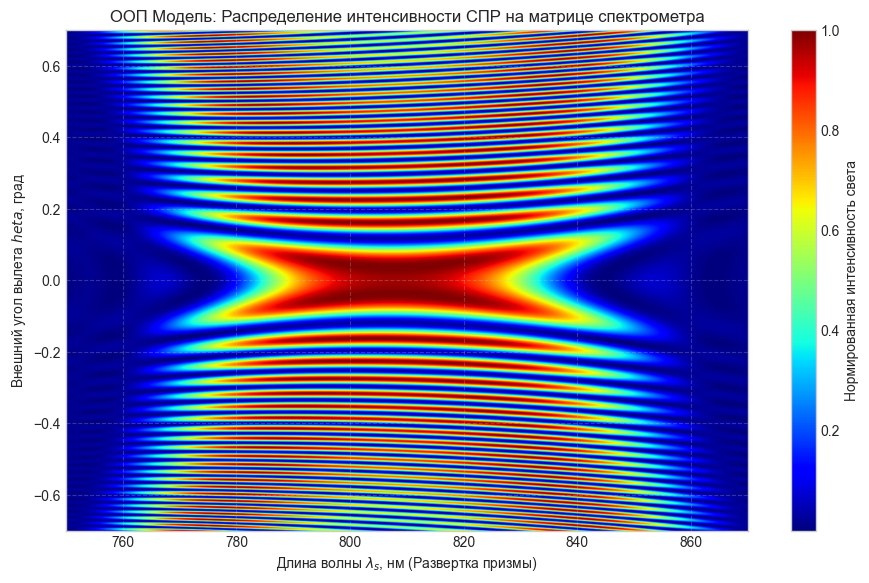

In [11]:
# Инициализируем материалы
air = Air()
bbo = BBO()
glass = GlassBK7()

# Создаем объект эксперимента (накачка 404 нм задана внутри по умолчанию)
experiment = SPDCExperiment()

# Набираем слои («пирог» нашего стенда)
experiment.add_layer(Layer(bbo, thickness=3.0e-3, pol_p="eff", is_source=True, name="Кристалл 1 (BBO)"))
experiment.add_layer(Layer(air, thickness=104e-3, is_source=False, name="Воздушный зазор 1"))
experiment.add_layer(Layer(bbo, thickness=4.3e-3, pol_p="eff", is_source=True, name="Кристалл 2 (BBO)"))

# 2. Строим 2D картинку интерференции, которая полетит на камеру спектрометра
experiment.plot_experiment_image(theta_range_deg=(-0.7, 0.7), lambda_range_nm=(750, 870))

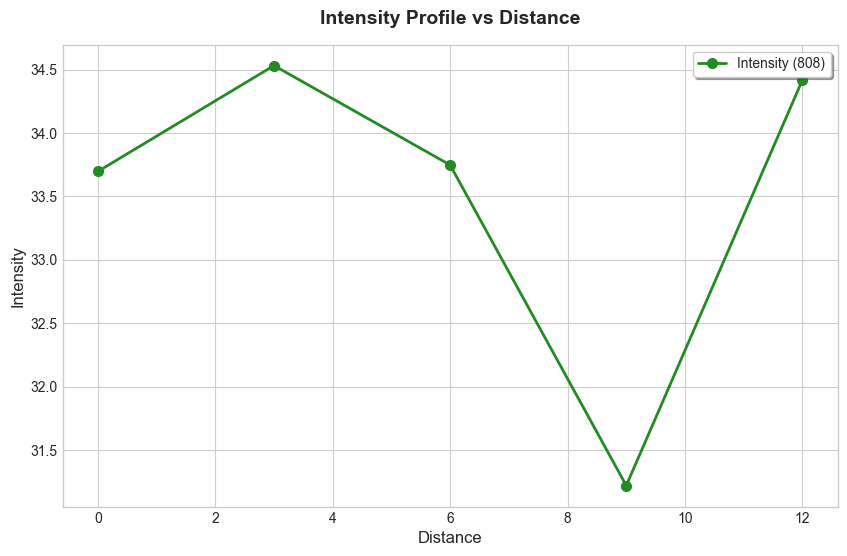

In [9]:

# Setting a nice style
plt.style.use('seaborn-v0_8-whitegrid') # or 'ggplot'

plt.figure(figsize=(10, 6))

plt.plot(df["distance"], df["intensity_808_exact"], "o-",
         color="forestgreen", markersize=7, linewidth=2,
         label="Intensity (808)")

# Labels and Title
plt.xlabel("Distance", fontsize=12)
plt.ylabel("Intensity", fontsize=12)
plt.title("Intensity Profile vs Distance", fontsize=14, fontweight='bold', pad=15)

# Legend
plt.legend(loc="upper right", frameon=True, shadow=True)